In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("desolationofsmaug/saraga-carnatic-music-dataset", force_download=True)

print("Path to dataset files:", path)
# print(kagglehub.dataset_download.__doc__)

100%|█████████████████████████████████████████████████████████████████████████████████████| 3.79G/3.79G [06:33<00:00, 10.4MB/s]

Extracting files...


Path to dataset files: /home/ananthakrishnan/.cache/kagglehub/datasets/desolationofsmaug/saraga-carnatic-music-dataset/versions/1


In [4]:
import librosa as lr
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import json

2025-03-25 21:56:05.199647: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-25 21:56:05.205352: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-25 21:56:05.222311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742939765.252545   30681 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742939765.261068   30681 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-25 21:56:05.291540: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [5]:
print(path)
file = open("path_to_dataset.txt", 'w')
file.write(path+"\n")
file.close()

/home/ananthakrishnan/.cache/kagglehub/datasets/desolationofsmaug/saraga-carnatic-music-dataset/versions/1


In [6]:
# getting all music files and ragas
os.chdir(path+'/carnatic')
dirs = os.listdir()
X = []
Xc = []
Xs = []
y = []
count = 0
base = "/home/ananthakrishnan/sem6/Neural Networks and Deep Learning/project/ragas/"
for i in dirs:
  # print(i)
  os.chdir(i)
  files = os.listdir()
  data = json.load(open([j for j in files if j.endswith('.json')][0]))
  # print(y)
  if len(data['raaga']) == 0 or data['raaga'][0]['name'] == "Rāgamālika":
    os.chdir("/home/ananthakrishnan/")
    nott = open("theese.txt", 'a')
    nott.write(i + '\n')
    nott.close()
    os.chdir(path+"/carnatic")
    continue
  count += 1
  musicFile = [j for j in files if j.endswith('.mp3')][0]
  mus, sr = lr.load(musicFile, duration=30.0)
  chromagram = lr.feature.chroma_cqt(y=mus, sr=sr)
  X.append(mus)
  Xc.append(chromagram)
  Xs.append(sr)
  raga = data['raaga'][0]['name']
  if not os.path.exists(base + raga):
    os.makedirs(base + raga)
  shutil.move(os.getcwd() + "/" + musicFile, base + "/" + raga + "/" + musicFile)
  y.append(raga)
  os.chdir(path+"/carnatic")

print(count)


176


In [8]:
dist = set(y)
print(len(dist))

95


In [13]:
dic = {}
for i in dist:
  dic[i] = y.count(i)
# plt.plot(dic.keys(), dic.values)
dic

{'Sindhubhairavi': 3,
 'Kalāvati': 1,
 'Karaharapriya': 2,
 'Latāngi': 1,
 'Puṇṇāgavarāḷi': 1,
 'Bhūṣāvaḷi': 1,
 'Rītigauḷa': 4,
 'Gauḷa': 2,
 'Śrī': 1,
 'Mōhanaṁ': 4,
 'Mandāri': 1,
 'Saurāṣtraṁ': 7,
 'Sindhumandāri': 1,
 'Ābhōgi': 2,
 'Kalyāṇi': 4,
 'Kathanakutūhalaṁ': 1,
 'Kāpi': 2,
 'Navrōj': 1,
 'Kāṁbhōji': 3,
 'Mārgahindōḷaṁ': 2,
 'Jōnpuri': 3,
 'Bēgaḍa': 3,
 'Gamakakriyā': 1,
 'Kānaḍa': 3,
 'Hindōḷaṁ': 1,
 'Sahānā': 2,
 'Sāranga': 1,
 'Sucaritra': 1,
 'Cittaranjani': 1,
 'Lalita pancamaṁ': 1,
 'Hussēnī': 1,
 'Pūrvīkaḷyāṇi': 1,
 'Mānḍu': 1,
 'Vasanta': 1,
 'Janaranjani': 1,
 'Hamīr kaḷyaṇi': 2,
 'Sāma': 1,
 'Āhiri': 1,
 'Yamuna kalyāṇi': 1,
 'Lalita': 2,
 'Ṣanmukhapriya': 4,
 'Suraṭi': 4,
 'Kuntalavarāḷi': 2,
 'Bahudāri': 1,
 'Kumudakriyā': 2,
 'Behāg': 5,
 'Harikāmbhōji': 3,
 'Madhyamāvati': 2,
 'Dēvagāndhāri': 1,
 'Tōḍi': 7,
 'Pāḍi': 2,
 'Hamsadhvani': 1,
 'Nāṭa': 2,
 'Sārāmati': 1,
 'Dhanyāsi': 1,
 'Simhēndra madhyamaṁ': 1,
 'Gaṁbhīra nāṭa': 1,
 'Kāmavardani/Pantuvarāḷi': 1,
 

In [15]:
'''plan: put the snippets (however many you can gather) into separate raga folders'''


3
1
2
1
1
1
4
2
1
4
1
7
1
2
4
1
2
1
3
2
3
3
1
3
1
2
1
1
1
1
1
1
1
1
1
2
1
1
1
2
4
4
2
1
2
5
3
2
1
7
2
1
2
1
1
1
1
1
1
1
7
5
3
1
1
1
2
2
1
1
1
1
1
1
1
1
2
2
2
1
2
3
1
2
1
2
1
1
1
2
2
1
1
2
1


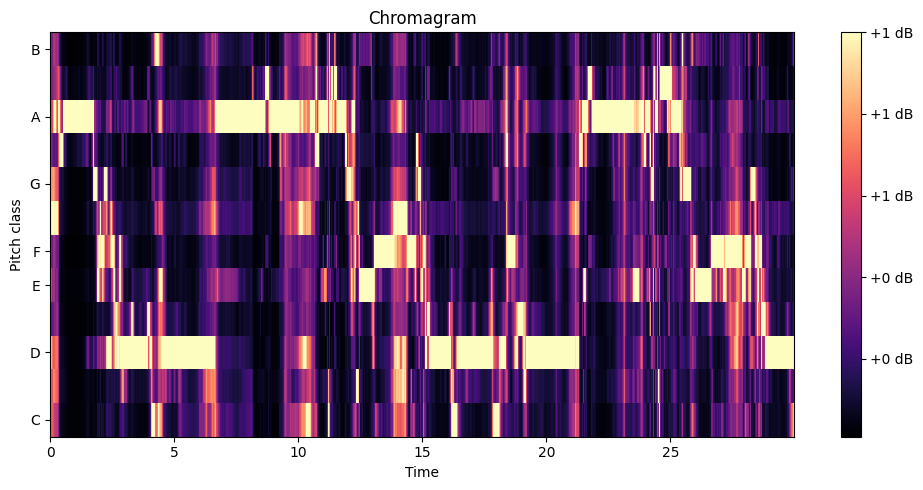

In [10]:
chromagram = lr.feature.chroma_cqt(y=X[0], sr=Xs[0])

# Display the chromagram
plt.figure(figsize=(10, 5))
lr.display.specshow(chromagram, sr=sr, x_axis='time', y_axis='chroma')
plt.title('Chromagram')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

In [11]:
from IPython.display import Audio
Audio(data=X[0], rate=Xs[0])

In [12]:
y[0]

'Sindhubhairavi'

In [ ]:
input = keras.Input(shape=(Xc[0].shape))

In [ ]:
os.chdir(path+'/carnatic/174')
files = os.listdir()
data = json.load(open([j for j in files if j.endswith('.json')][0]))
data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# sphinx_gallery_thumbnail_path = '_static/playback-thumbnail.png'

import librosa

# We'll need IPython.display's Audio widget
from IPython.display import Audio

# We'll also use `mir_eval` to synthesize a signal for us
# import mir_eval.sonify

y, sr = librosa.load(music[0], duration=30.0)
print(y)
Audio(data=y, rate=sr)

In [ ]:
fp = open(music[0].split('.')[0] + '.json')
ob = json.load(fp)
ob['raaga'][0]['name']